# News Title Clustering
This project applies unsupervised learning to group news titles into meaningful clusters using TF-IDF text representations and engineered numerical features. Multiple clustering algorithms are compared, and the discovered clusters are profiled and assigned human-readable topic names.

## 1. Data Understanding
- Load `news.csv`
- Inspect dataset shape
- Check missing titles
- Check duplicate titles
- Preserve `True_Category` only for final external evaluation
- `True_Category` must NOT be used for clustering

In [30]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack
from scipy.optimize import linear_sum_assignment
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    accuracy_score, adjusted_rand_score, normalized_mutual_info_score
)

# 1. LOAD DATA
df = pd.read_csv("news.csv")

if "Final_Category" in df.columns:
    label_col = "Final_Category"
elif "Category" in df.columns:
    label_col = "Category"
else:
    raise ValueError("Category/Final_Category column not found")

df = df[["Title", label_col]].rename(columns={label_col: "True_Category"})

print("Original shape:", df.shape)
print("Missing titles:", df["Title"].isna().sum())
print("Duplicate titles:", df["Title"].duplicated().sum())

Original shape: (4997, 2)
Missing titles: 0
Duplicate titles: 423


## 2. Data Cleaning
- Convert titles to lowercase
- Remove URLs
- Remove punctuation
- Remove extra spaces
- Remove empty and duplicate cleaned titles

In [31]:
# 2. CLEANING
def clean_title(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["Clean_Title"] = df["Title"].apply(clean_title)
df = df[df["Clean_Title"] != ""].drop_duplicates("Clean_Title").reset_index(drop=True)

print("After cleaning:", df.shape)

After cleaning: (4449, 3)


## 3. Feature Engineering
We extract several numerical features from the cleaned titles to capture structural and topical information:
- `word_count`
- `char_count`
- `avg_word_length`
- `unique_word_ratio`
- `number_count`
- `year_present`
- `trending_keyword_count`
- `poi_count`
- `company_keyword_count`

In [32]:
# 3. FEATURE ENGINEERING
trending = ["ai","bitcoin","crypto","stock","stocks","oil","election","inflation","earnings","tariff","chip","war","market"]
poi = ["usa","us","china","pakistan","india","europe","uk","russia","israel","washington","london"]
companies = ["nvidia","microsoft","google","apple","tesla","amazon","meta","openai"]

def count_keywords(text, keywords):
    words = text.split()
    return sum(word in keywords for word in words)

df["word_count"] = df["Clean_Title"].apply(lambda x: len(x.split()))
df["char_count"] = df["Clean_Title"].apply(len)
df["avg_word_length"] = df["Clean_Title"].apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
df["unique_word_ratio"] = df["Clean_Title"].apply(lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0)
df["number_count"] = df["Clean_Title"].apply(lambda x: len(re.findall(r"\b\d+(?:\.\d+)?\b", x)))
df["year_present"] = df["Clean_Title"].apply(lambda x: int(bool(re.search(r"\b20\d{2}\b", x))))
df["trending_keyword_count"] = df["Clean_Title"].apply(lambda x: count_keywords(x, trending))
df["poi_count"] = df["Clean_Title"].apply(lambda x: count_keywords(x, poi))
df["company_keyword_count"] = df["Clean_Title"].apply(lambda x: count_keywords(x, companies))

num_cols = [
    "word_count","char_count","avg_word_length","unique_word_ratio",
    "number_count","year_present","trending_keyword_count",
    "poi_count","company_keyword_count"
]

## 4. TF-IDF Text Features
**TF** = Term Frequency
**IDF** = Inverse Document Frequency

TF-IDF converts news titles into numerical vectors.
`ngram_range=(1,2)` captures individual words and two-word phrases.
`max_features=3000` performs feature limitation/selection.

In [33]:
# 4. TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=3000
)

X_text = tfidf.fit_transform(df["Clean_Title"])
terms = tfidf.get_feature_names_out()

print("TF-IDF shape:", X_text.shape)

TF-IDF shape: (4449, 3000)


## 5. Candidate Features
Clustering uses:
- TF-IDF text features
- Engineered numerical features

## 6. Feature Selection
`max_features=3000` and `min_df=2` are used to keep useful TF-IDF features.

## 7. Feature Scaling
`StandardScaler` scales numerical features so different numerical ranges do not unfairly affect distance calculations.

In [34]:
# 5. SCALE + COMBINE
scaler = StandardScaler()
X_num = scaler.fit_transform(df[num_cols])

NUMERIC_WEIGHT = 1.0
X = hstack([X_text, X_num * NUMERIC_WEIGHT])

## 8. Dimensionality Reduction
`TruncatedSVD` reduces the high-dimensional feature space to 50 components so clustering becomes easier and faster.

In [35]:
# 6. SVD
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X)

print("Reduced shape:", X_reduced.shape)

Reduced shape: (4449, 50)


## 9. Exploratory Data Analysis
A quick visualization of the word-count graph.

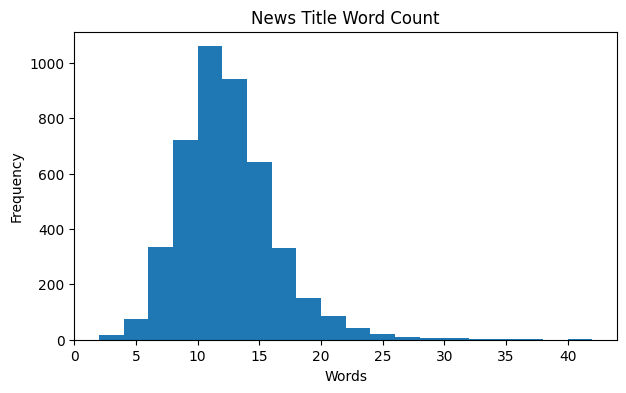

In [36]:
# 7. EDA
plt.figure(figsize=(7,4))
plt.hist(df["word_count"], bins=20)
plt.title("News Title Word Count")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

## 10. Finding the Number of Clusters
- **Elbow Method** uses inertia/WCSS
- **Silhouette Score** measures cluster separation and compactness
- Elbow and Silhouette analysis are used to inspect different values of K. K=6 is used for the final experiment to obtain a practical and interpretable six-cluster solution.

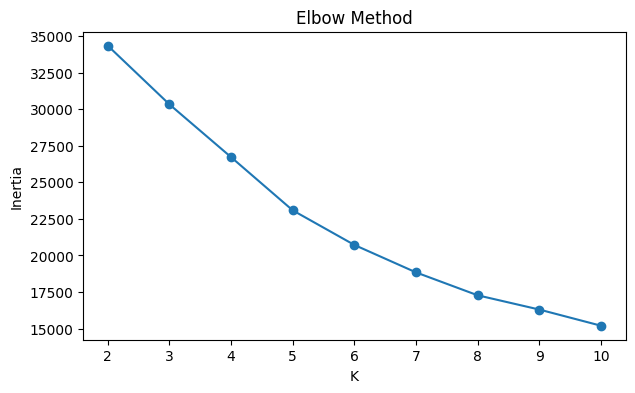

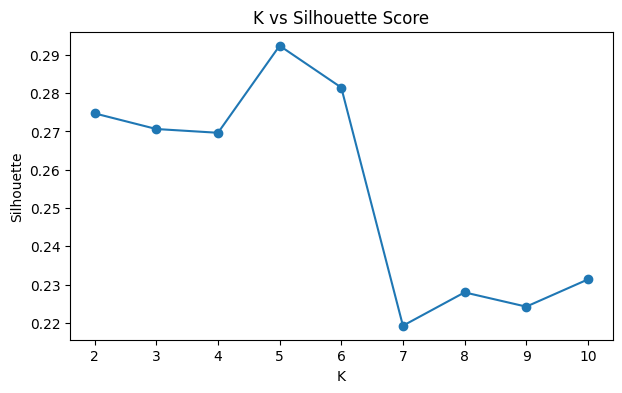

In [37]:
# 8. K SELECTION
ks = range(2, 11)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_reduced, labels))

plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(list(ks), silhouettes, marker="o")
plt.title("K vs Silhouette Score")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.show()

K = 6

## 11. Candidate Clustering Models
Four algorithms are compared:
1. KMeans
2. Agglomerative Clustering
3. Gaussian Mixture Model
4. DBSCAN

In [38]:
# 9. MODELS
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_reduced)

agg = AgglomerativeClustering(n_clusters=K)
agg_labels = agg.fit_predict(X_reduced)

gmm = GaussianMixture(n_components=K, random_state=42)
gmm_labels = gmm.fit_predict(X_reduced)

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_reduced)

## 12. Internal Cluster Evaluation
- **Silhouette Score**: Higher is better.
- **Davies-Bouldin Score**: Lower is better.
- **Calinski-Harabasz Score**: Higher is better.
- **Noise Points**: Mainly relevant for DBSCAN.

In [39]:
# 10. INTERNAL EVALUATION
def internal_metrics(name, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    y = labels[mask]
    Xv = X_reduced[mask]

    clusters = len(np.unique(y))
    noise = int(np.sum(labels == -1))

    if clusters < 2:
        return [name, clusters, np.nan, np.nan, np.nan, noise]

    return [
        name, clusters,
        silhouette_score(Xv, y),
        davies_bouldin_score(Xv, y),
        calinski_harabasz_score(Xv, y),
        noise
    ]

comparison = pd.DataFrame([
    internal_metrics("KMeans", kmeans_labels),
    internal_metrics("Agglomerative", agg_labels),
    internal_metrics("GaussianMixture", gmm_labels),
    internal_metrics("DBSCAN", dbscan_labels)
], columns=["Model","Clusters","Silhouette","Davies_Bouldin","Calinski_Harabasz","Noise_Points"])

print("\nINTERNAL EVALUATION")
print(comparison.to_string(index=False))


INTERNAL EVALUATION
          Model  Clusters  Silhouette  Davies_Bouldin  Calinski_Harabasz  Noise_Points
         KMeans         6    0.281452        1.288999         853.660485             0
  Agglomerative         6    0.271681        1.410509         813.780445             0
GaussianMixture         6    0.068793        3.065139         294.669898             0
         DBSCAN        33    0.011375        0.867909         125.910444          1754


## 13. External Evaluation
`True_Category` was NOT used to create clusters. It is used only after clustering to compare discovered clusters with predefined categories.

- **Clustering Accuracy** uses optimal cluster-to-category matching using the Hungarian algorithm.
- **ARI** measures agreement between cluster assignments and true labels.
- **NMI** measures shared information between clusters and true categories.

Clustering accuracy is not the primary metric for unsupervised clustering.

In [40]:
# 11. EXTERNAL EVALUATION
def external_metrics(name, true_labels, cluster_labels):
    true_labels = np.asarray(true_labels)
    cluster_labels = np.asarray(cluster_labels)

    mask = pd.notna(true_labels) & (cluster_labels != -1)
    y_true = true_labels[mask]
    y_cluster = cluster_labels[mask]

    ari = adjusted_rand_score(y_true, y_cluster)
    nmi = normalized_mutual_info_score(y_true, y_cluster)

    table = pd.crosstab(y_cluster, y_true)
    rows, cols = linear_sum_assignment(-table.values)
    mapping = {table.index[r]: table.columns[c] for r, c in zip(rows, cols)}

    predicted = [mapping.get(c, "Unknown") for c in y_cluster]
    acc = accuracy_score(y_true, predicted)

    return [name, acc, ari, nmi, len(y_true), int(np.sum(cluster_labels == -1))]

external = pd.DataFrame([
    external_metrics("KMeans", df["True_Category"], kmeans_labels),
    external_metrics("Agglomerative", df["True_Category"], agg_labels),
    external_metrics("GaussianMixture", df["True_Category"], gmm_labels),
    external_metrics("DBSCAN", df["True_Category"], dbscan_labels)
], columns=["Model","Clustering_Accuracy","ARI","NMI","Evaluated_Points","Noise_Excluded"])

print("\nEXTERNAL EVALUATION")
print(external.to_string(index=False))


EXTERNAL EVALUATION
          Model  Clustering_Accuracy       ARI      NMI  Evaluated_Points  Noise_Excluded
         KMeans             0.309733  0.010764 0.056402              4449               0
  Agglomerative             0.305462  0.014509 0.056704              4449               0
GaussianMixture             0.366599  0.028632 0.100088              4449               0
         DBSCAN             0.279777 -0.003339 0.065463              2695            1754


## 14. Best Model Selection
KMeans is selected as the final model because it provides the strongest overall internal clustering quality among the six-cluster candidate models and supports prediction for unseen titles.

In [41]:
# 12. FINAL BEST MODEL
best_model_name = "KMeans"
df["Cluster"] = kmeans_labels

print("\nBest Analysis Model:", best_model_name)
print("\nKMeans Cluster Sizes:")
print(df["Cluster"].value_counts().sort_index())


Best Analysis Model: KMeans

KMeans Cluster Sizes:
Cluster
0    2128
1     568
2     179
3     638
4     407
5     529
Name: count, dtype: int64


## 15. Cluster Profiling
Clusters are interpreted using:
- cluster size
- top TF-IDF terms
- trending keyword average
- POI average
- company keyword average
- sample news titles

In [42]:
# 13. PROFILING
def top_terms(labels, cluster_id, n=10):
    idx = np.where(np.asarray(labels) == cluster_id)[0]
    sums = X_text[idx].sum(axis=0).A1
    top = sums.argsort()[::-1][:n]
    return [terms[i] for i in top]

def profile(labels, name):
    labels = np.asarray(labels)

    for c in sorted(np.unique(labels)):
        if c == -1:
            continue

        part = df[labels == c]

        print(f"\n=== {name} Cluster {c} ===")
        print("Size:", len(part))
        print("Top terms:", ", ".join(top_terms(labels, c)))
        print("Avg trending:", round(part["trending_keyword_count"].mean(), 2))
        print("Avg POI:", round(part["poi_count"].mean(), 2))
        print("Avg company:", round(part["company_keyword_count"].mean(), 2))

        for title in part["Title"].sample(min(3, len(part)), random_state=42):
            print("-", title)

profile(kmeans_labels, "KMeans")


=== KMeans Cluster 0 ===
Size: 2128
Top terms: new, says, announces, trump, shares, higher, million, global, group, profit
Avg trending: 0.0
Avg POI: 0.0
Avg company: 0.0
- Morgan Stanley's Profit Surges, Powered by Dealmaking, Trading Revenue
- Galway Hires Stephen Poitras to Help Advance the High-Grade Estrades Gold and Zinc Project
- Prologis Shares Gain on Raised Outlook, Data Center Growth

=== KMeans Cluster 1 ===
Size: 568
Top terms: ai, stock, stocks, market, earnings, oil, crypto, inflation, bank, bitcoin
Avg trending: 1.21
Avg POI: 0.02
Avg company: 0.0
- Sheikh Tahnoon meets Jay-Z to discuss Abu Dhabi’s AI-powered economic transition
- LVMH's third quarter suggests the slump in demand has bottomed - triggering a surge in luxury stocks
- Matador Acquires 5 Bitcoin for CAD$810,733, Bringing Its Total Bitcoin (and Bitcoin Equivalent) Holdings to 82

=== KMeans Cluster 2 ===
Size: 179
Top terms: nvidia, apple, ai, openai, meta, amazon, microsoft, data, pro, google
Avg trending:

## 16. Manual Cluster Naming
Cluster IDs such as 0,1,2 are arbitrary, therefore human-readable topic names are assigned AFTER profiling.

- 0 -> Business
- 1 -> Markets
- 2 -> Technology
- 3 -> Corporate Announcements & Finance
- 4 -> Earnings & Financial Results
- 5 -> Politics

In [43]:
# 14. KMEANS MANUAL CATEGORY NAMES
kmeans_cluster_names = {

    0: "Business",

    1: "Markets",

    2: "Technology",

    3: "Corporate Announcements & Finance",

    4: "Earnings & Financial Results",

    5: "Politics"

}

df["Assigned_Category"] = df["Cluster"].map(kmeans_cluster_names)

print("\nSample Final Categories:")
print(df[["Title","Cluster","Assigned_Category"]].head(10).to_string(index=False))


Sample Final Categories:
                                                                              Title  Cluster                 Assigned_Category
                        Vietnam Airlines data leak exposes a crisis of transparency        0                          Business
                         DOJ seizes $15 billion bitcoin in SE Asia crypto scam bust        1                           Markets
        Think It's Too Late to Buy IonQ? Here's the 1 Reason Why There's Still Time        3 Corporate Announcements & Finance
                                Intel's Crucial Panther Lake Chips Start Production        0                          Business
                                                3 Robotics Stocks to Buy in October        1                           Markets
Think It's Too Late to Buy Applied Digital? Here's 1 Reason Why There's Still Time.        3 Corporate Announcements & Finance
                                                        Transcript: UK Budget blues  

## 17. Outlier / Noise Detection
DBSCAN identifies noise using cluster label -1.
KMeans itself assigns every point to a cluster.

In [44]:
# 15. DBSCAN NOISE
noise_indices = np.where(dbscan_labels == -1)[0]
print("\nDBSCAN Noise Points:", len(noise_indices))

if len(noise_indices) > 0:
    noise_titles = df.iloc[noise_indices]["Title"]
    print("\nSample Noise Titles:")
    for title in noise_titles.sample(min(5, len(noise_titles)), random_state=42):
        print("-", title)


DBSCAN Noise Points: 1754

Sample Noise Titles:
- Computershare Ltd higher Wednesday, outperforms the Information Technology sector
- Huawei affiliates parade products that fuel China chip ambitions
- Xiaomi driver death adds to China’s push for new EV door designs
- 8th Pay Commission Calculator: How 2.86 Fitment Factor Will Increase HRA For Level 1â3 Government Employees?
- Infratil Says CDC To Announce New Partnership With Firmus Technologies And Nvidia


## 18. Deployment
KMeans is used for deployment because it supports predict() for unseen titles.

The prediction pipeline:
New Title
↓
Cleaning
↓
Engineered Features
↓
TF-IDF
↓
Scaling
↓
Feature Combination
↓
SVD
↓
KMeans Prediction
↓
Human-readable Cluster Name

In [45]:
# 16. DEPLOYMENT
def make_num_features(text):
    words = text.split()

    values = [[
        len(words),
        len(text),
        np.mean([len(w) for w in words]) if words else 0,
        len(set(words)) / len(words) if words else 0,
        len(re.findall(r"\b\d+(?:\.\d+)?\b", text)),
        int(bool(re.search(r"\b20\d{2}\b", text))),
        count_keywords(text, trending),
        count_keywords(text, poi),
        count_keywords(text, companies)
    ]]

    return pd.DataFrame(values, columns=num_cols)

def predict_title(title):
    clean = clean_title(title)

    text_vec = tfidf.transform([clean])
    num_vec = scaler.transform(make_num_features(clean))

    combined = hstack([text_vec, num_vec * NUMERIC_WEIGHT])
    reduced = svd.transform(combined)

    cluster = int(kmeans.predict(reduced)[0])
    category = kmeans_cluster_names.get(cluster, "Unknown")

    return cluster, category

test_title = "Nvidia launches new AI chip for datacenters"

cluster, category = predict_title(test_title)

print("\nDEPLOYMENT TEST")
print("Title:", test_title)
print("Predicted Cluster:", cluster)
print("Category:", category)


DEPLOYMENT TEST
Title: Nvidia launches new AI chip for datacenters
Predicted Cluster: 2
Category: Technology


## 19. Save Results
The final clustered dataset, internal model comparison, and external evaluation metrics are saved as separate CSV files for analysis and reporting.

In [46]:
# 17. SAVE OUTPUTS
df[[
    "Title",
    "Clean_Title",
    "True_Category",
    "Cluster",
    "Assigned_Category"
]].to_csv("clustered_news.csv", index=False)

comparison.to_csv("clustering_model_comparison.csv", index=False)
external.to_csv("clustering_external_evaluation.csv", index=False)

print("\nSaved:")
print("- clustered_news.csv")
print("- clustering_model_comparison.csv")
print("- clustering_external_evaluation.csv")


Saved:
- clustered_news.csv
- clustering_model_comparison.csv
- clustering_external_evaluation.csv


## 20. Conclusion

Best Model: KMeans
Number of Clusters: 6
Silhouette Score: 0.281452
Davies-Bouldin Score: 1.288999
Calinski-Harabasz Score: 853.660485
Clustering Accuracy: 0.309733 (30.97%)
ARI: 0.010764
NMI: 0.056402
Deployment Model: KMeans
DBSCAN Noise Points: 1754

The external clustering accuracy is relatively low because clustering is unsupervised and the naturally discovered groups do not necessarily correspond exactly to the predefined dataset categories. Therefore, internal clustering metrics and cluster interpretability are important when selecting the final model.